# 16TFcluster — L1 SCENIC AUC: TF-level UMAP
Read the L1 combined SCENIC AUC AnnData (cells x regulons), transpose to (TF regulons x cells),
assign each TF the cell-type group where its mean AUC is highest, run PCA -> neighbours -> UMAP,
and plot one point per TF regulon coloured by that group.

Data: `/data2/junyi/stg0901/scenic_auc_L1_h5ad/combined_auc_all.h5ad` (~1.34M cells x 966 regulons, dense float32).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
h5ad_path = "/data2/junyi/stg0901/scenic_auc_L1_h5ad/combined_auc_all.h5ad"
group_col = "celltype.L1"      # column in .obs used to colour TFs (alternatives: celltype.L1, Neurotransmitter_celltype, Region_NT)
out_dir = "figures/tfcluster_L1"
os.makedirs(out_dir, exist_ok=True)

# memory control: cap cells per group. Set to None to use all cells (needs ~10-15 GB RAM).
MAX_CELLS_PER_GROUP = 3000
print(f"group_col = {group_col}, MAX_CELLS_PER_GROUP = {MAX_CELLS_PER_GROUP}")

group_col = celltype.L1, MAX_CELLS_PER_GROUP = 3000


In [3]:
# load AnnData (backed), subsample to MAX_CELLS_PER_GROUP per group to keep X in memory
adata = ad.read_h5ad(h5ad_path, backed="r")
print("full shape:", adata.shape)


full shape: (1338788, 966)


In [5]:
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,umap_seurat_1,umap_seurat_2,celltype,Neurotransmitter,region_celltypeL2_condition,condition,dataset,Region_NT,pallium,pallium_NT
AAACGAACACCGTACG-1AMY_seekgene_FC38A-0,FC38A_AMY_seekgene,1579.0,7.365180,3548.0,8.174421,42.869222,48.252537,55.496054,69.588501,6.0,...,2.067845,1.807289,Astrocyte-1,NN,NaN,NaN,0,Astrocyte,Subpallium,Astrocyte
AAACGAACACTAATCG-1AMY_seekgene_FC38A-0,FC38A_AMY_seekgene,1506.0,7.317876,3313.0,8.105911,43.042560,48.717175,55.780260,69.634772,3.0,...,2.799509,0.122868,Astrocyte-1,NN,NaN,NaN,0,Astrocyte,Subpallium,Astrocyte
AAACGAACAGATCATC-1AMY_seekgene_FC38A-0,FC38A_AMY_seekgene,1465.0,7.290293,3357.0,8.119101,44.712541,49.836163,57.164135,71.254096,0.0,...,2.211223,2.623897,Astrocyte-1,NN,NaN,NaN,0,Astrocyte,Subpallium,Astrocyte
AAACGAACAGGCATGA-1AMY_seekgene_FC38A-0,FC38A_AMY_seekgene,1460.0,7.286876,3003.0,8.007700,40.692641,46.353646,53.613054,68.031968,4.0,...,1.528468,0.772858,Astrocyte-1,NN,NaN,NaN,0,Astrocyte,Subpallium,Astrocyte
AAACGAACAGGGTATG-1AMY_seekgene_FC38A-0,FC38A_AMY_seekgene,1487.0,7.305188,3150.0,8.055475,40.825397,46.380952,54.285714,68.666667,0.0,...,1.554093,1.915233,Astrocyte-1,NN,NaN,NaN,0,Astrocyte,Subpallium,Astrocyte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATTCGTTGTAGACAGC-1TH_beirui_CSRS10-3-67,CSRS10-3_TH_beirui,1437.0,7.271009,2361.0,7.767264,26.556544,32.952139,41.846675,60.313427,6.0,...,8.006076,-1.412816,VLMC,NN,NaN,NaN,67,Vascular,TH,Vascular
GTCACTCAGTGTGTTC-1TH_beirui_CSRS1-3-67,CSRS1-3_TH_beirui,1183.0,7.076654,1736.0,7.459915,26.785714,32.603687,43.375576,60.656682,2.0,...,6.385415,-5.540723,VLMC,NN,NaN,NaN,67,Vascular,TH,Vascular
TCTTGCGTCAGACCTA-1TH_beirui_CSRS1-3-67,CSRS1-3_TH_beirui,1255.0,7.135687,2028.0,7.615298,29.043393,35.108481,44.970414,62.771203,2.0,...,-1.693517,-14.056318,VSMC,NN,NaN,NaN,67,Vascular,TH,Vascular
GGTTCTCGTCCATCTC-1TH_beirui_CSRS9-1-67,CSRS9-1_TH_beirui,1032.0,6.940222,1742.0,7.463363,36.222732,41.963261,52.238806,69.460390,3.0,...,-1.547843,-13.610380,VSMC,NN,NaN,NaN,67,Vascular,TH,Vascular


In [7]:
MAX_CELLS_PER_GROUP = None
if MAX_CELLS_PER_GROUP is not None:
    idx = []
    rng = np.random.default_rng(0)
    for _, grp in adata.obs.groupby(group_col, observed=True):
        names = grp.index.tolist()
        if len(names) > MAX_CELLS_PER_GROUP:
            names = list(rng.choice(names, size=MAX_CELLS_PER_GROUP, replace=False))
        idx.extend(names)
    adata = adata[idx].to_memory()
else:
    adata = adata.to_memory()
print("working shape:", adata.shape)

working shape: (1338788, 966)


In [8]:
# transpose: rows become TF regulons, columns become (subsampled) cells
adata_T = adata.T.copy()
adata_T.X = np.asarray(adata_T.X, dtype=np.float32)
print("transposed:", adata_T.shape)  # expect (n_TF_regulons, n_cells)

transposed: (966, 1338788)


In [27]:
# for each TF, find the cell-type group in which its AUC is highest on average
# pallium_NT etc. may be categorical: coerce to plain str first
groups = adata_T.var[group_col].astype("object").fillna("NA").astype(str)
group_names = sorted(set(groups))
mat = np.asarray(adata_T.X)  # (n_TF x n_cells)
# mean AUC per group (columns of X are cells)
means = pd.DataFrame(mat.T, columns=adata_T.obs_names)  # (cells x TFs)
means[group_col] = groups.values
grp_mean = means.groupby(group_col).mean()              # (groups x TFs)
group_mean_obs = grp_mean.T.add_prefix("group_mean_")  # (TFs x groups)
adata_T.obs = adata_T.obs.drop(columns=group_mean_obs.columns, errors="ignore").join(group_mean_obs)
assert adata_T.obs.index.equals(group_mean_obs.index)
print("added group mean columns to adata_T.obs:", group_mean_obs.shape[1])
best = grp_mean.T.idxmax(axis=1)                        # per TF: argmax group
adata_T.obs["active_" + group_col] = best.values
adata_T.obs["active_frac"] = (grp_mean.T.max(axis=1) / grp_mean.T.sum(axis=1)).values
print(adata_T.obs["active_" + group_col].value_counts().to_string())
# --- extra: for each TF, % of cells with non-zero AUC in each cell-type group ---
# (proportion of cells where the regulon is active), output as a TF x group matrix
grp_of_cell = groups.values                      # one group label per cell
nonz = (mat > 0).astype(np.float32)              # 1 where AUC != 0  (AUC >= 0)

pct_nz = {}
for g in sorted(set(grp_of_cell)):
    m = grp_of_cell == g
    if m.sum() == 0:
        continue
    pct_nz[g] = nonz[:, m].mean(axis=1) * 100    # % cells with AUC>0, per TF in this group
df_pct = pd.DataFrame(pct_nz, index=adata_T.obs_names)
df_pct.index.name = "TF"
df_pct = df_pct.round(3)
# add one pct_nz column per cell-type group to the TF-level AnnData obs
pct_nz_obs = df_pct.add_prefix("pct_nz_")
adata_T.obs = adata_T.obs.drop(columns=pct_nz_obs.columns, errors="ignore").join(pct_nz_obs)
assert adata_T.obs.index.equals(pct_nz_obs.index)
print("added pct_nz columns to adata_T.obs:", pct_nz_obs.shape[1])
df_pct.to_csv(os.path.join(out_dir, f"tf_pct_nz_by_{group_col}.csv"))
print("\nnon-zero AUC fraction (TF x group):", df_pct.shape, "->",
      os.path.join(out_dir, f"tf_pct_nz_by_{group_col}.csv"))
df_pct.iloc[:5, :5]



added group mean columns to adata_T.obs: 13
Immune       198
Microglia    155
Astrocyte    106
Oligo         96
Vascular      83
OPC           72
Epen          64
GABA          45
Chol          37
Sero          34
Dopa          30
Glut          26
Hist          20
added pct_nz columns to adata_T.obs: 13

non-zero AUC fraction (TF x group): (966, 13) -> figures/tfcluster_L1/tf_pct_nz_by_celltype.L1.csv


,Astrocyte,Chol,Dopa,Epen,GABA
TF,,,,,
1810024B03Rik(+),1.526,2.562,3.127,0.251,0.000
2010315B03Rik(+),7.195,7.066,0.000,0.264,2.481
2610044O15Rik8(+),0.000,0.000,0.000,0.000,0.000
3300002I08Rik(+),0.000,0.000,0.000,1.665,0.000
6720489N17Rik(+),0.000,0.000,0.000,0.000,0.000


In [91]:
adata_N = adata_T[:,adata_T.var['Neurotransmitter_celltype'] != 'NN'].copy()

In [ ]:
adata_NN = adata_N[:,adata_N.var['Neurotransmitter_celltype'] == 'NN'].copy()

In [92]:
# recompute active group and fraction after removing NN cells
group_col_n = "region"
group_col_n = group_col
groups_N = adata_N.var[group_col_n].astype("object").fillna("NA").astype(str)
mat_N = np.asarray(adata_N.X)
means_N = pd.DataFrame(mat_N.T, columns=adata_N.obs_names)
means_N[group_col_n] = groups_N.values
grp_mean_N = means_N.groupby(group_col_n).mean()
# softmax across cell types for each TF; probabilities sum to 1 per TF
grp_mean_N_shifted = grp_mean_N.subtract(grp_mean_N.max(axis=0), axis=1)
group_softmax_N = np.exp(grp_mean_N_shifted)
group_softmax_N = group_softmax_N.div(group_softmax_N.sum(axis=0), axis=1)
group_softmax_obs_N = group_softmax_N.T.add_prefix("group_softmax_")
adata_N.obs = adata_N.obs.drop(columns=group_softmax_obs_N.columns, errors="ignore").join(group_softmax_obs_N)
assert np.allclose(group_softmax_N.sum(axis=0).to_numpy(), 1.0)
active_N = grp_mean_N.T.idxmax(axis=1)
active_frac_N = grp_mean_N.T.max(axis=1).div(grp_mean_N.T.sum(axis=1).replace(0, np.nan))
adata_N.obs["active_" + group_col_n] = active_N.reindex(adata_N.obs_names).values
adata_N.obs["active_frac"] = active_frac_N.reindex(adata_N.obs_names).values
print("recomputed active group and active_frac for adata_N:", adata_N.shape)
print(adata_N.obs["active_" + group_col_n].value_counts().to_string())

recomputed active group and active_frac for adata_N: (966, 1051351)
Chol    430
GABA    187
Dopa     95
Sero     90
Hist     82
Glut     82


In [93]:
# dimension reduction on the TF x cell matrix
sc.pp.pca(adata_N, n_comps=50, svd_solver="arpack" if min(adata_N.shape) > 50 else "full")
sc.pp.neighbors(adata_N, n_neighbors=30, n_pcs=50)
sc.tl.umap(adata_N, random_state=0)
print("PCA + UMAP done")


PCA + UMAP done


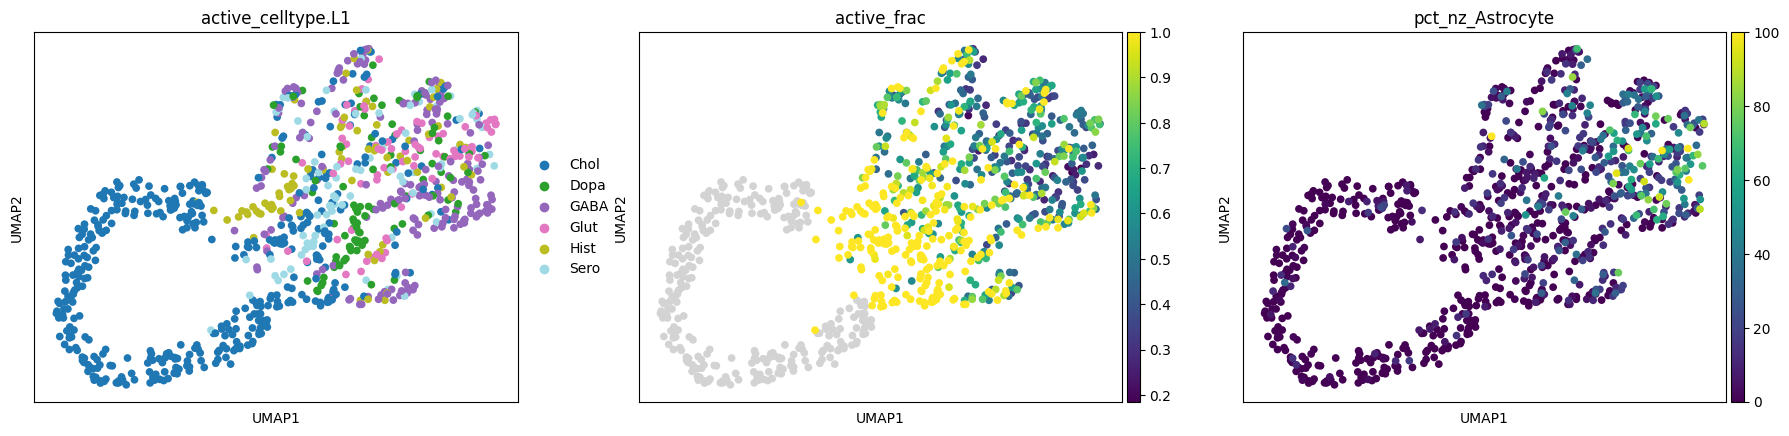

In [95]:
sc.pl.umap(
    adata_N,
    color=["active_" + group_col, "active_frac","pct_nz_Astrocyte"],
    palette="tab20",
    save=f"_tfcluster_{group_col}.png")

In [88]:
pcts = [c for c in adata_N.obs.columns if c.startswith("pct_nz_")]
group_mean_cols = [c for c in adata_N.obs.columns if c.startswith("group_softmax_")]

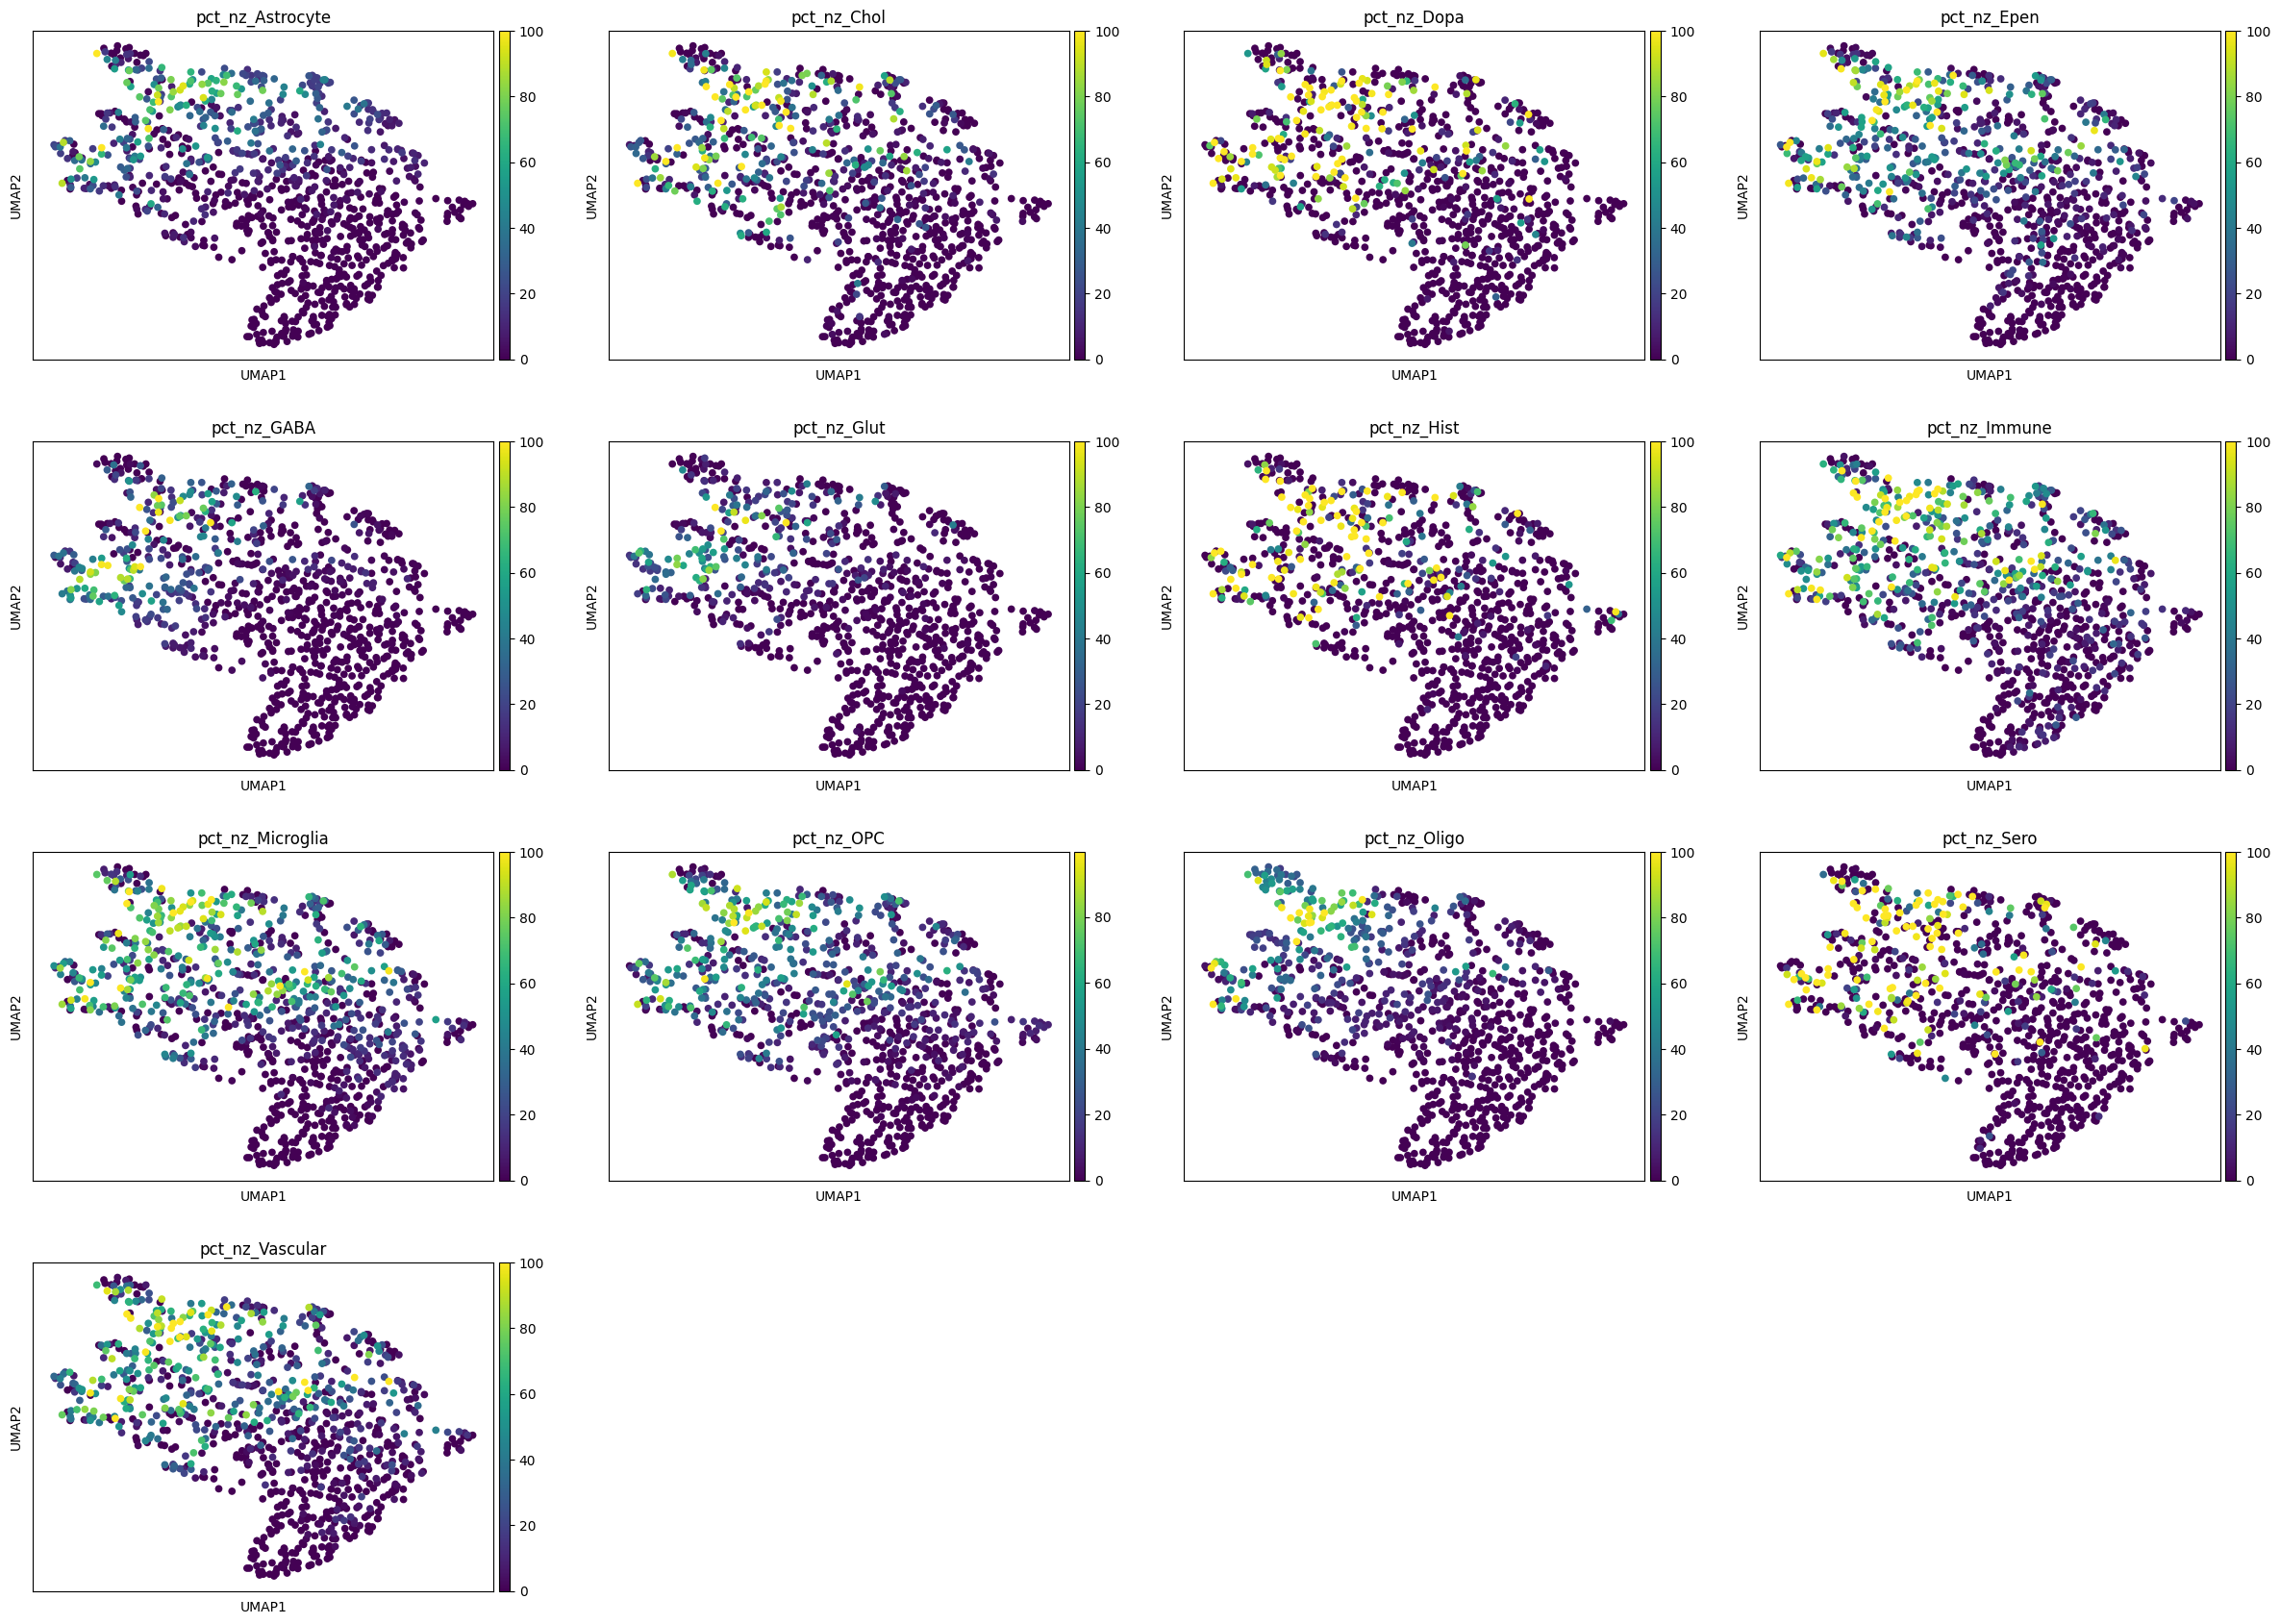

In [89]:
sc.pl.umap(
    adata_N,
    color=pcts
)

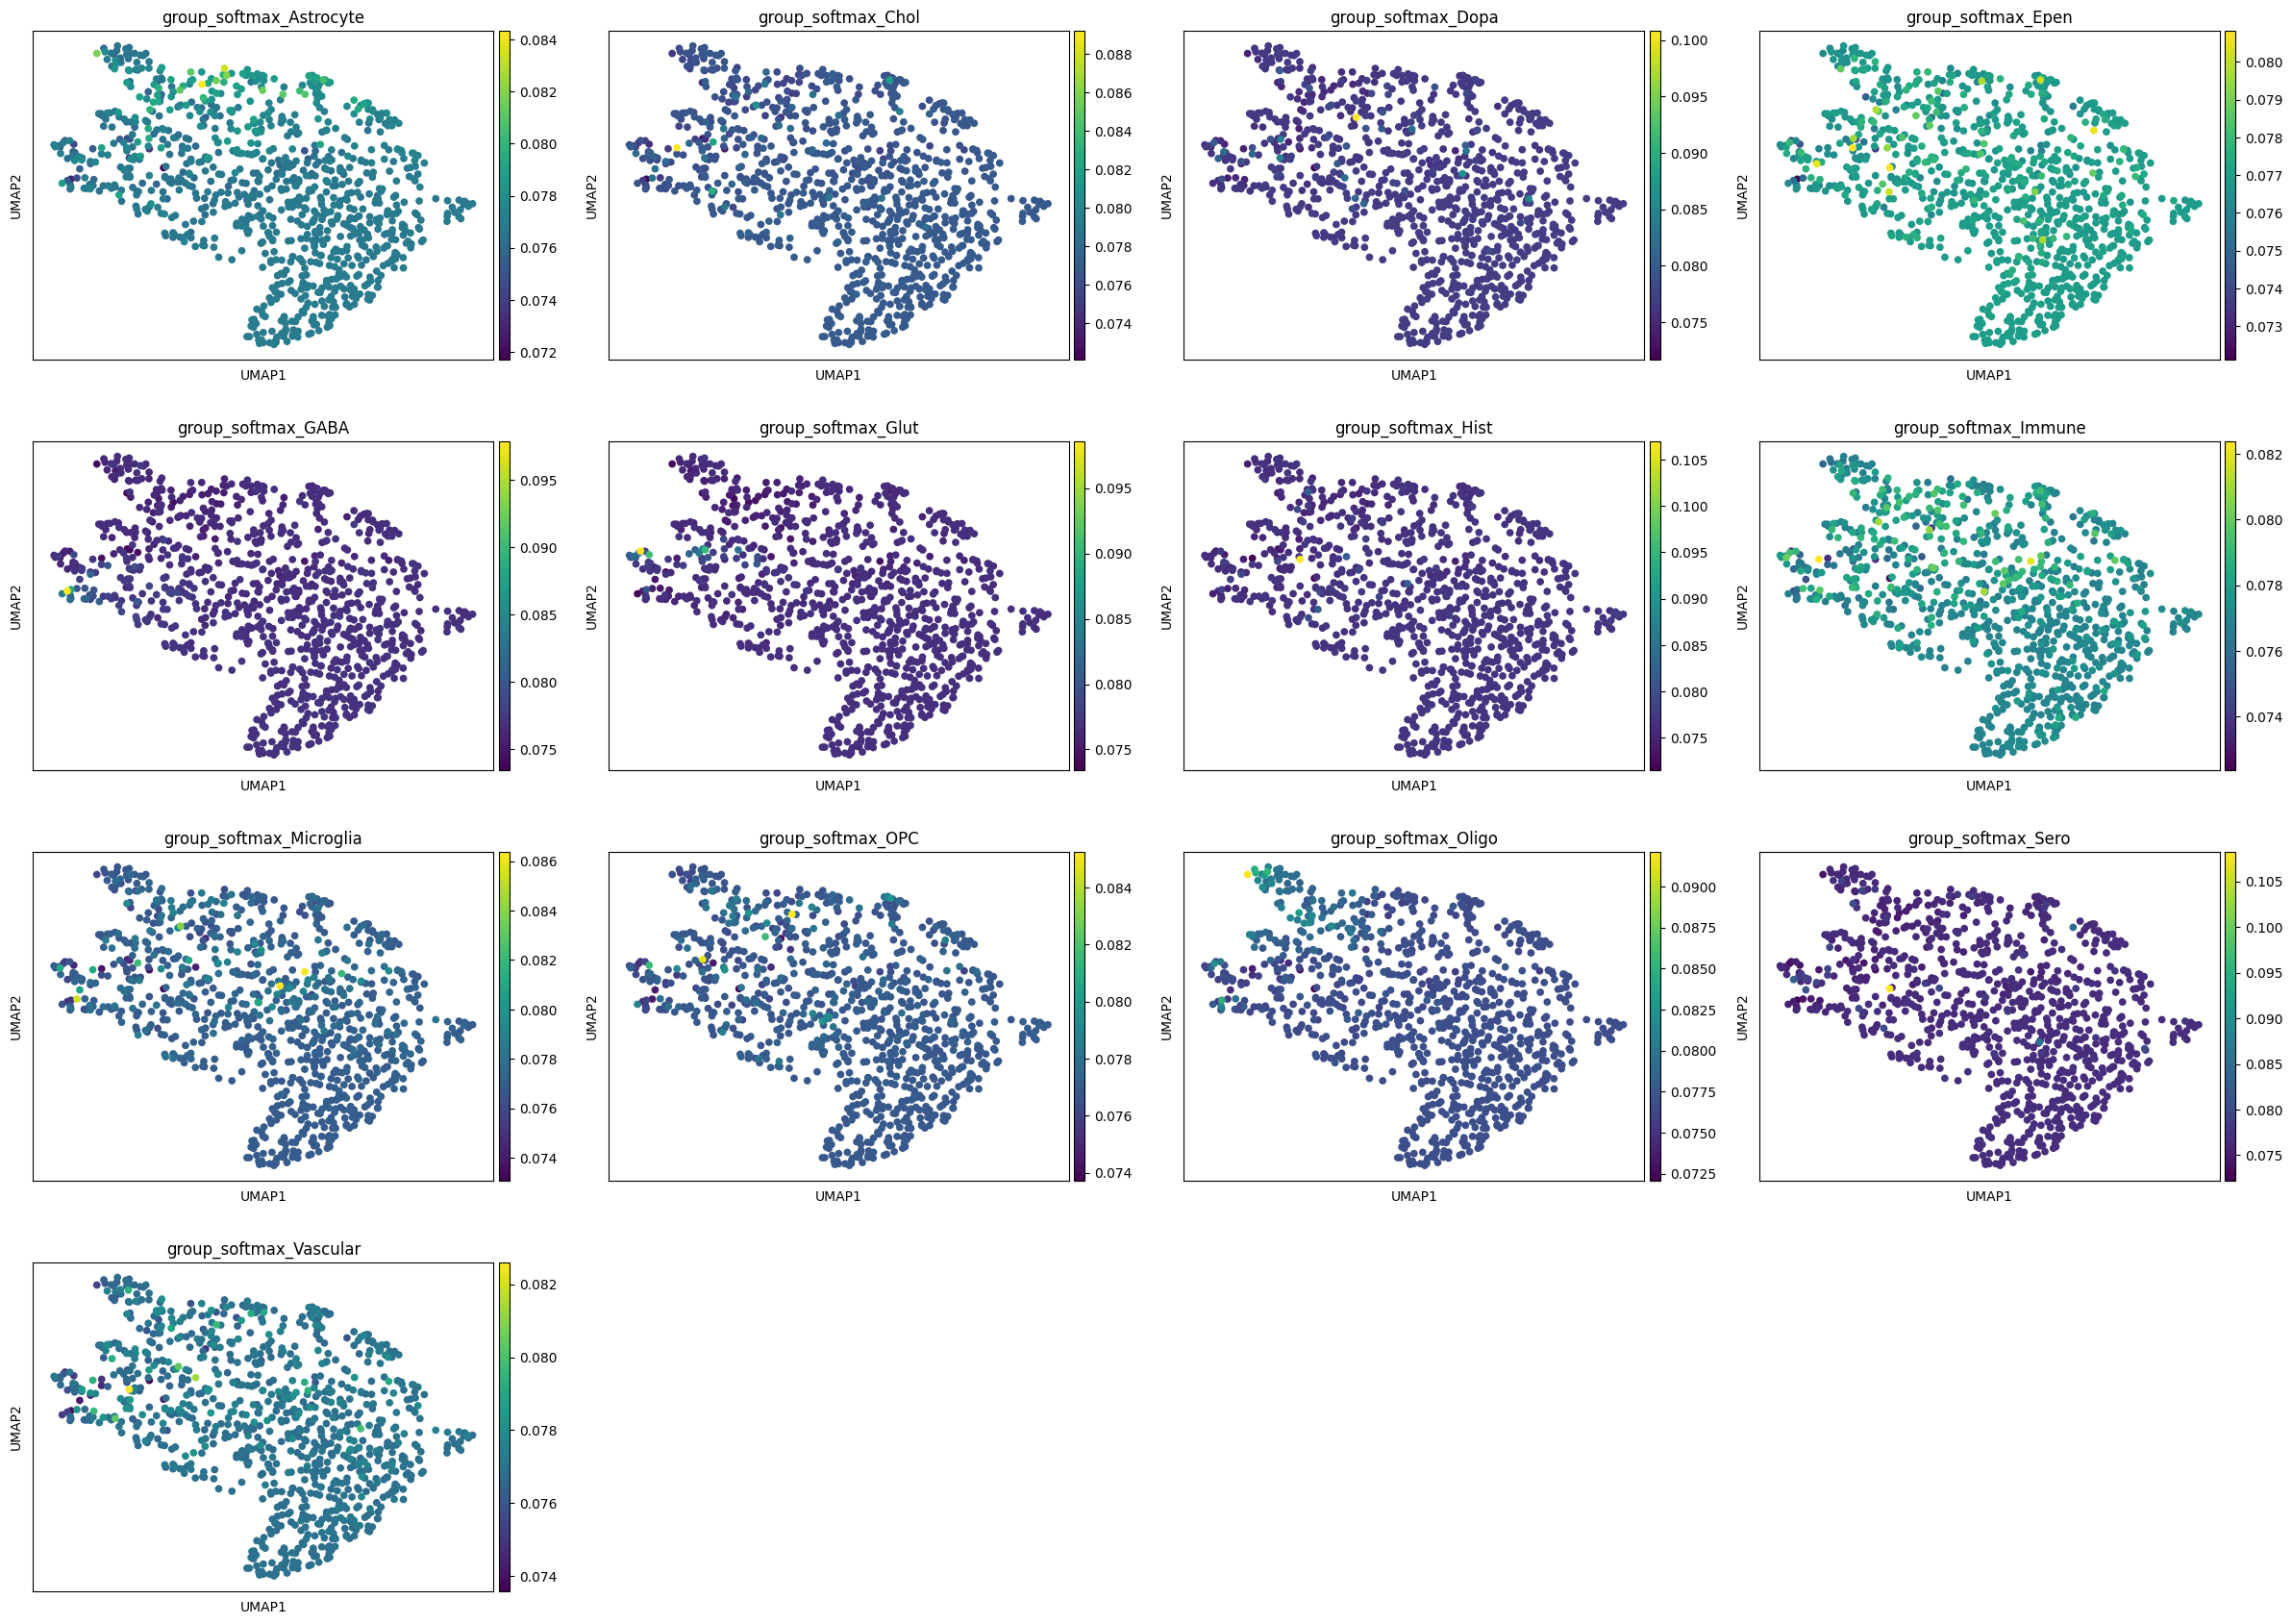

In [90]:
sc.pl.umap(
    adata_N,
    color=group_mean_cols
)

In [14]:
adata_T.obs

,active_celltype.L1,active_frac
1810024B03Rik(+),Immune,0.417441
2010315B03Rik(+),Microglia,0.420587
2610044O15Rik8(+),Vascular,1.000000
3300002I08Rik(+),Microglia,0.555841
6720489N17Rik(+),Oligo,1.000000
...,...,...
Zscan26(+),Oligo,0.848515
Zscan29(+),Astrocyte,0.878515
Zswim1(+),Vascular,1.000000
Zxdb(+),Microglia,0.926073


In [ ]:
adata_T.write_h5ad(os.path.join(out_dir, "tf_level_umap_L1.h5ad"))

In [ ]:
# UMAP: one point per TF regulon, coloured by its most-active cell-type group
color_col = "active_" + group_col
fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(adata_T, color=color_col, ax=ax, show=False, legend_loc="right margin", legend_fontsize=7,
           palette="tab20", title=f"SCENIC L1 TF regulons (n={adata_T.n_obs})")
# label a few isolated TFs? default no text labels; uncomment to draw all TF names at low alpha
# for i, tf in enumerate(adata_T.obs_names):
#     ax.text(adata_T.obsm["X_umap"][i,0], adata_T.obsm["X_umap"][i,1], tf, fontsize=5, alpha=0.6)
ax.set_title(f"TF-level UMAP by {group_col} (L1)")
plt.tight_layout()
fig.savefig(os.path.join(out_dir, f"tf_umap_L1_{group_col}.png"), dpi=200)
plt.show()

In [ ]:
# (optional) numeric summary / export of each TF's active group + UMAP coords
df_tf = pd.DataFrame({
    "TF": adata_T.obs_names,
    "active_" + group_col: adata_T.obs["active_" + group_col].values,
    "active_frac": adata_T.obs["active_frac"].values,
    "UMAP1": adata_T.obsm["X_umap"][:, 0],
    "UMAP2": adata_T.obsm["X_umap"][:, 1],
})
df_tf.to_csv(os.path.join(out_dir, "tf_level_umap_L1.csv"), index=False)
print(df_tf.head())